In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
Sales_data = pd.read_csv('AmazonSales_data.zip')
Sales_data

,order_id,order_date,product_id,product_category,price,discount_percent,quantity_sold,customer_region,payment_method,rating,review_count,discounted_price,total_revenue
0,1,2022-04-13,2637,Books,128.75,10,4,North America,UPI,3.5,443,115.88,463.52
1,2,2023-03-12,2300,Fashion,302.60,20,5,Asia,Credit Card,3.7,475,242.08,1210.40
2,3,2022-09-28,3670,Sports,495.80,20,2,Europe,UPI,4.4,183,396.64,793.28
3,4,2022-04-17,2522,Books,371.95,15,4,Middle East,UPI,5.0,212,316.16,1264.64
4,5,2022-03-13,1717,Beauty,201.68,0,4,Middle East,UPI,4.6,308,201.68,806.72
...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,49996,2022-09-03,1433,Beauty,26.99,0,5,Middle East,Credit Card,2.4,386,26.99,134.95
49996,49997,2022-07-03,1428,Beauty,294.23,10,5,Asia,Credit Card,3.1,8,264.81,1324.05
49997,49998,2023-02-17,4651,Electronics,352.11,30,4,Asia,Debit Card,3.1,104,246.48,985.92
49998,49999,2022-09-30,4371,Beauty,307.54,5,1,Middle East,UPI,1.8,316,292.16,292.16


In [3]:
#Sales_data.isnull().sum()

In [39]:
# here I'm wanting to see which product categories has the most quantity sold.

df = Sales_data.groupby('product_category')['quantity_sold'].sum().reset_index().sort_values('quantity_sold', ascending=False)
df



,product_category,quantity_sold
0,Beauty,25422
3,Fashion,25089
1,Books,25065
2,Electronics,24898
5,Sports,24753
4,Home & Kitchen,24743


In [40]:
# Next I'm wanting to see what product categories are top 3 in total revenue.
revenue = (
    Sales_data.groupby('product_category')['total_revenue']
    .sum().reset_index().sort_values('total_revenue', ascending=False)
)

revenue.style.format({'total_revenue': '${:,.2f}'})

,product_category,total_revenue
0,Beauty,"$5,550,624.97"
1,Books,"$5,484,863.03"
3,Fashion,"$5,480,123.34"
4,Home & Kitchen,"$5,473,132.55"
2,Electronics,"$5,470,594.03"
5,Sports,"$5,407,235.82"


In [41]:
# here i want to find out what the revenue would be without discounts and how much potential revenue was lost

Sales_data['full_price_revenue'] = Sales_data['price'] * Sales_data['quantity_sold']

Sales_data['revenue_lost'] = Sales_data['full_price_revenue'] - Sales_data['total_revenue']

Sales_data

,order_id,order_date,product_id,product_category,price,discount_percent,quantity_sold,customer_region,payment_method,rating,review_count,discounted_price,total_revenue,expected_revenue,full_price_revenue,revenue_lost
0,1,2022-04-13,2637,Books,128.75,10,4,North America,UPI,3.5,443,115.88,463.52,515.00,515.00,51.48
1,2,2023-03-12,2300,Fashion,302.60,20,5,Asia,Credit Card,3.7,475,242.08,1210.40,1513.00,1513.00,302.60
2,3,2022-09-28,3670,Sports,495.80,20,2,Europe,UPI,4.4,183,396.64,793.28,991.60,991.60,198.32
3,4,2022-04-17,2522,Books,371.95,15,4,Middle East,UPI,5.0,212,316.16,1264.64,1487.80,1487.80,223.16
4,5,2022-03-13,1717,Beauty,201.68,0,4,Middle East,UPI,4.6,308,201.68,806.72,806.72,806.72,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,49996,2022-09-03,1433,Beauty,26.99,0,5,Middle East,Credit Card,2.4,386,26.99,134.95,134.95,134.95,0.00
49996,49997,2022-07-03,1428,Beauty,294.23,10,5,Asia,Credit Card,3.1,8,264.81,1324.05,1471.15,1471.15,147.10
49997,49998,2023-02-17,4651,Electronics,352.11,30,4,Asia,Debit Card,3.1,104,246.48,985.92,1408.44,1408.44,422.52
49998,49999,2022-09-30,4371,Beauty,307.54,5,1,Middle East,UPI,1.8,316,292.16,292.16,307.54,307.54,15.38


In [42]:
discount_impact = (
    Sales_data.groupby('product_category')
    .agg(
        full_price_revenue=('full_price_revenue', 'sum'),
        actual_revenue=('total_revenue', 'sum'),
        revenue_lost=('revenue_lost', 'sum'),
        avg_discount=('discount_percent', 'mean')
    )
    .reset_index()
    .sort_values('revenue_lost', ascending=False)
)

discount_impact.style.format({
    'full_price_revenue': '${:,.2f}',
    'actual_revenue': '${:,.2f}',
    'revenue_lost': '${:,.2f}',
    'avg_discount': '{:.1f}%'
})

,product_category,full_price_revenue,actual_revenue,revenue_lost,avg_discount
0,Beauty,"$6,404,986.46","$5,550,624.97","$854,361.49",13.4%
1,Books,"$6,335,208.84","$5,484,863.03","$850,345.81",13.3%
5,Sports,"$6,252,366.06","$5,407,235.82","$845,130.24",13.4%
3,Fashion,"$6,319,842.15","$5,480,123.34","$839,718.81",13.4%
2,Electronics,"$6,303,168.52","$5,470,594.03","$832,574.49",13.3%
4,Home & Kitchen,"$6,297,532.51","$5,473,132.55","$824,399.96",13.3%


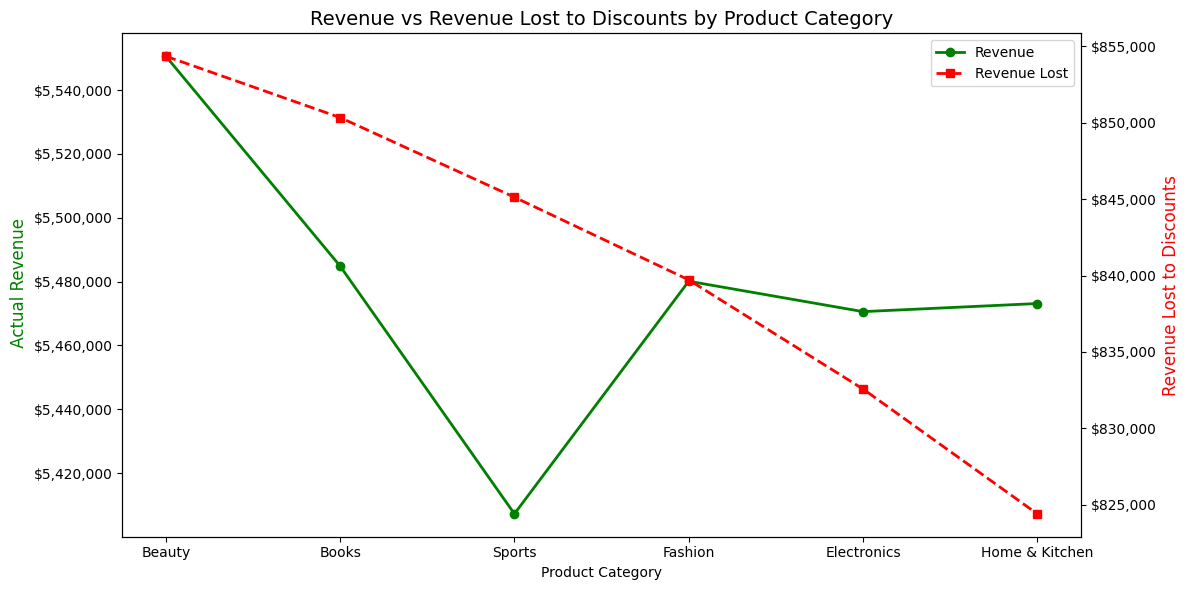

In [43]:
fig, ax1 = plt.subplots(figsize=(12, 6))

# Line 1 -  Revenue (left axis)
ax1.plot(discount_impact['product_category'], discount_impact['actual_revenue'],
         marker='o', linewidth=2, color='Green', label='Revenue')
ax1.set_ylabel(' Actual Revenue', color='Green', fontsize=12)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax1.tick_params(axis='y', labelcolor='black')

# Line 2 - Revenue Lost (right axis)
ax2 = ax1.twinx()
ax2.plot(discount_impact['product_category'], discount_impact['revenue_lost'],
         marker='s', linewidth=2, color='red', linestyle='--', label='Revenue Lost')
ax2.set_ylabel('Revenue Lost to Discounts', color='red', fontsize=12)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax2.tick_params(axis='y', labelcolor='black')

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

ax1.set_xlabel('Product Category')
ax1.set_title('Revenue vs Revenue Lost to Discounts by Product Category', fontsize=14)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

In [44]:
# here I was curious if the products rating had any influence on the amount it was disounted 
rating_vs_discount = (
    Sales_data.groupby('product_category')
    .agg(
        avg_rating=('rating','mean'),
        avg_discount=('discount_percent','mean'),
        quantity_sold=('quantity_sold', 'sum')
    )
    .reset_index()
    
    
)      
rating_vs_discount.style.format({
    'avg_discount': '{:.1f}%',
    'avg_rating': '{:.2f}'
})



,product_category,avg_rating,avg_discount,quantity_sold
0,Beauty,2.99,13.4%,25422
1,Books,3.02,13.3%,25065
2,Electronics,2.99,13.3%,24898
3,Fashion,2.99,13.4%,25089
4,Home & Kitchen,3.00,13.3%,24743
5,Sports,3.00,13.4%,24753


In [51]:
#here im seeing what products were the most discounted
sales_summary = (
    Sales_data.groupby('product_category')
    .agg(
        revenue_lost=('revenue_lost', 'sum'),
        total_revenue=('total_revenue', 'sum')
    )
    .reset_index()
    .sort_values('revenue_lost',ascending=False)
)

sales_summary.style.format({'total_revenue': '${:,.2f}', 'revenue_lost': '${:,.2f}'})


,product_category,revenue_lost,total_revenue
0,Beauty,"$854,361.49","$5,550,624.97"
1,Books,"$850,345.81","$5,484,863.03"
5,Sports,"$845,130.24","$5,407,235.82"
3,Fashion,"$839,718.81","$5,480,123.34"
2,Electronics,"$832,574.49","$5,470,594.03"
4,Home & Kitchen,"$824,399.96","$5,473,132.55"


In [47]:
# Now im interested in which region has the most sales and which has the most total revenue 
region_sales = Sales_data.groupby('customer_region')['quantity_sold'].sum().reset_index().sort_values('quantity_sold', ascending=False)
region_sales

,customer_region,quantity_sold
2,Middle East,37694
3,North America,37534
0,Asia,37440
1,Europe,37302


In [48]:
region_summary = (
    Sales_data.groupby('customer_region')
    .agg(
        total_sales=('quantity_sold', 'sum'),
        total_revenue=('total_revenue', 'sum'),
        revenue_lost=('revenue_lost', 'sum')
    )
    .reset_index()
    .sort_values('total_sales', ascending=False)
)

region_summary.style.format({'total_revenue': '${:,.2f}','revenue_lost': '${:,.2f}'})

,customer_region,total_sales,total_revenue,revenue_lost
2,Middle East,37694,"$8,301,844.50","$1,267,824.46"
3,North America,37534,"$8,277,217.84","$1,256,156.65"
0,Asia,37440,"$8,175,199.83","$1,274,937.84"
1,Europe,37302,"$8,112,311.57","$1,247,611.85"


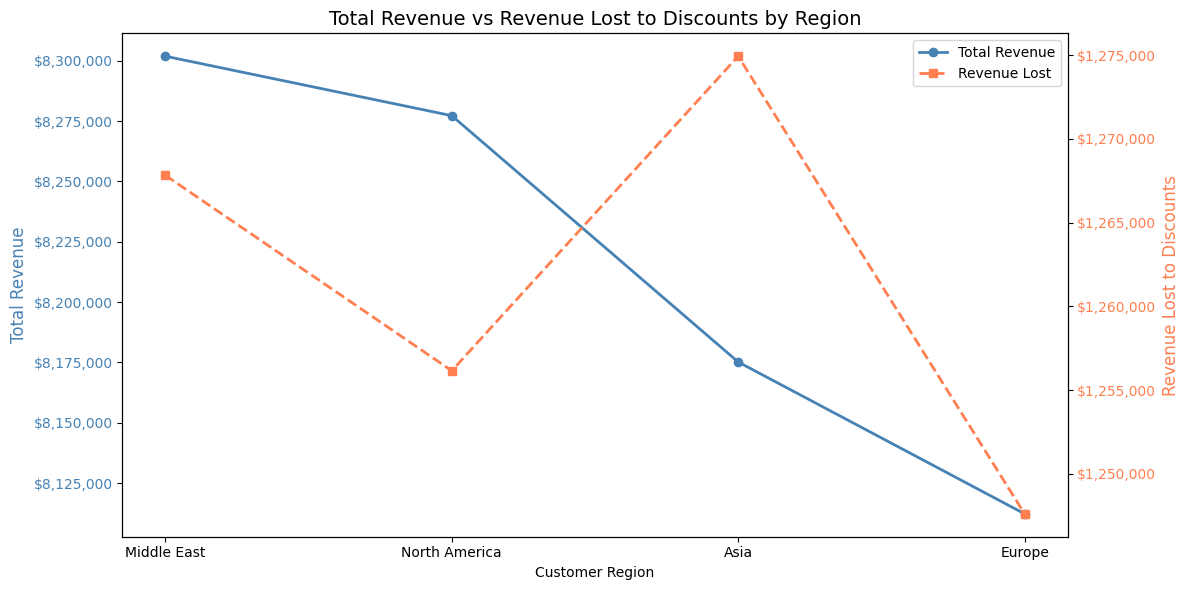

In [49]:
import matplotlib.pyplot as plt


fig, ax1 = plt.subplots(figsize=(12, 6))

# Line 1 - Total Revenue (left axis)
ax1.plot(region_summary['customer_region'], region_summary['total_revenue'],
         marker='o', linewidth=2, color='steelblue', label='Total Revenue')
ax1.set_ylabel('Total Revenue', color='steelblue', fontsize=12)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax1.tick_params(axis='y', labelcolor='steelblue')

# Line 2 - Revenue Lost (right axis)
ax2 = ax1.twinx()
ax2.plot(region_summary['customer_region'], region_summary['revenue_lost'],
         marker='s', linewidth=2, color='coral', linestyle='--', label='Revenue Lost')
ax2.set_ylabel('Revenue Lost to Discounts', color='coral', fontsize=12)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax2.tick_params(axis='y', labelcolor='coral')

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

ax1.set_xlabel('Customer Region')
ax1.set_title('Total Revenue vs Revenue Lost to Discounts by Region', fontsize=14)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

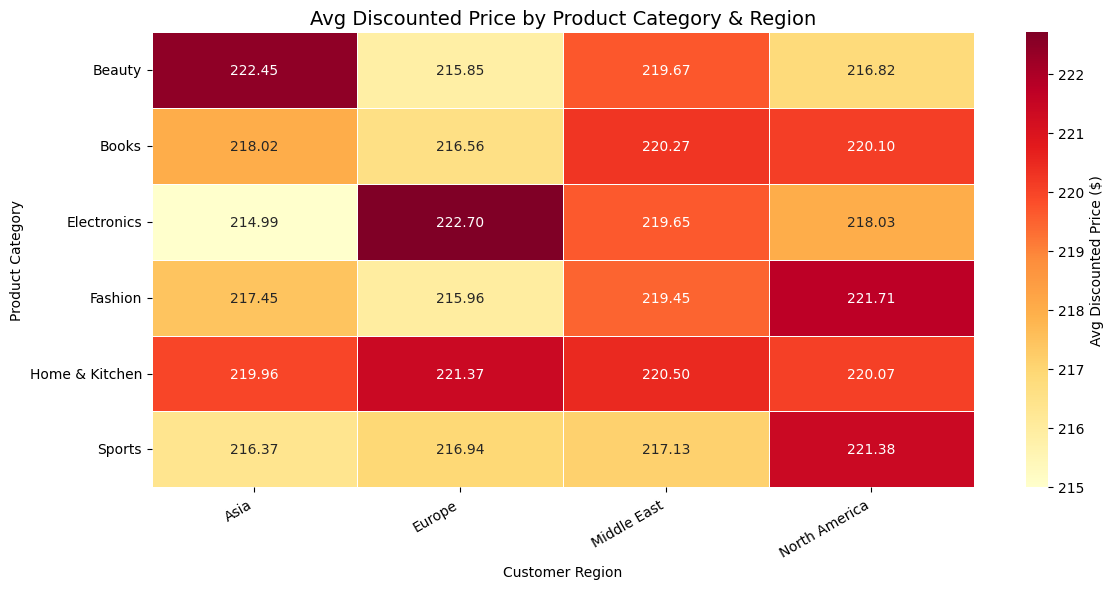

In [50]:
import matplotlib.ticker as mticker
import seaborn as sns

heatmap_data = (
    Sales_data.groupby(['product_category', 'customer_region'])['discounted_price']
    .mean()
    .unstack()
)

plt.figure(figsize=(12, 6))
sns.heatmap(
    heatmap_data,
    annot=True,
    fmt='.2f',
    cmap='YlOrRd',
    linewidths=0.5,
    cbar_kws={'label': 'Avg Discounted Price ($)'}
)
plt.title('Avg Discounted Price by Product Category & Region', fontsize=14)
plt.xlabel('Customer Region')
plt.ylabel('Product Category')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()


SUMMARY BASED OF THE DATA
North America presented the biggest positive gap between revenue and revenue lost. The Asian region took the most advantage of the discount prices. 


In [38]:
#Payment method preference based region

In [ ]:
#what product category for which region